In [95]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", "UserWarning")

import numpy as np
import scipy.linalg as sl
import h5py

# for plotting
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

from tdinf import group_postprocess, utils, run_sampler, waveform_h5s

In [96]:
import os
print(os.listdir('output'))

['pre_-0.01seconds.dat', 'pre_0.01seconds.dat', 'pre_0.04seconds.dat', 'pre_-0.05seconds.dat', 'full_0.0seconds.dat', 'pre_0.05seconds.dat']


In [97]:
filename_dict = {
    'full': 'full_0.0seconds',
    'pre_-0.05': 'pre_-0.05seconds',
    'pre_-0.01': 'pre_-0.01seconds',
    'pre_0.01': 'pre_0.01seconds',
    'pre_0.04': 'pre_0.04seconds',
    'pre_0.05': 'pre_0.05seconds',
}

In [98]:
from utils.preprocessing import get_ACF
from utils.whiten import whitenData_TD

In [120]:
f = h5py.File("../L-L1_GWOSC_16KHZ_R2-1242442952-32.hdf5", "r")

strain_L1 = f["strain"]["Strain"][:]

f= h5py.File("../H-H1_GWOSC_16KHZ_R2-1242442952-32.hdf5", "r")

strain_H1 = f["strain"]["Strain"][:]

data_dict = {
    "H1": strain_H1,
    "L1": strain_L1}


In [128]:
#define psd and time arrays
psd_dict = {
    "H1": np.genfromtxt("../glitch_median_PSD_H1.dat")[:-2000, :],
    "L1": np.genfromtxt("../glitch_median_PSD_L1.dat")[:-2000, :],}

dt = 1/16384

time_dict = {
    "H1": np.arange(0, len(strain_H1)*dt, dt),
    "L1": np.arange(0, len(strain_L1)*dt, dt)
}

In [129]:
len(data_dict["H1"]),
len(time_dict["H1"])

524288

In [130]:
# factor of 42 more than acf, select every 42nd sample
data_ds = {ifo: data_dict[ifo][::42] for ifo in data_dict}
time_ds = {ifo: time_dict[ifo][::42] for ifo in time_dict}

for ifo in data_ds:
    print(ifo, len(data_ds[ifo]))
    print(ifo, len(time_ds[ifo]))

H1 12484
H1 12484
L1 12484
L1 12484


In [131]:
# Trim extra to match ACF exactly. ACF length is 12382
acf_len = len(acf["H1"])

for ifo in data_ds:
    data_ds[ifo] = data_ds[ifo][:acf_len]
    time_ds[ifo] = time_ds[ifo][:acf_len]

In [132]:
# define and call ACF function
acf = get_ACF(psd_dict, time_dict, f_low=11, f_max=None, nan_inf_replacement=10000000000.0, patch=None, return_psds=False)

In [133]:
data_dict['H1'], acf['H1']

(array([-6.99731895e-21,  2.60948206e-21, -2.39383950e-22, ...,
        -3.68357864e-20, -1.61826545e-20, -1.26952939e-20],
       shape=(524288,)),
 array([6.43860591e-37, 6.43611872e-37, 6.42971568e-37, ...,
        6.41945923e-37, 6.42971568e-37, 6.43611872e-37],
       shape=(12382,)))

In [134]:
len(acf["H1"])

12382

In [135]:
whitened_data = {}

for ifo in data_ds:
    whitened_data[ifo] = whitenData_TD(data_ds[ifo], acf[ifo])

In [136]:
print(whitened_data)

{'H1': array([-8.72038679e-03,  1.29951212e+00, -1.80097892e+00, ...,
       -7.67681953e+01, -1.00844010e+02, -8.98340107e+01],
      shape=(12382,)), 'L1': array([ 6.57467883e-03,  5.12498209e-02, -1.42904344e+01, ...,
        5.40540336e+01,  5.39026512e+01,  1.32855707e+02],
      shape=(12382,))}


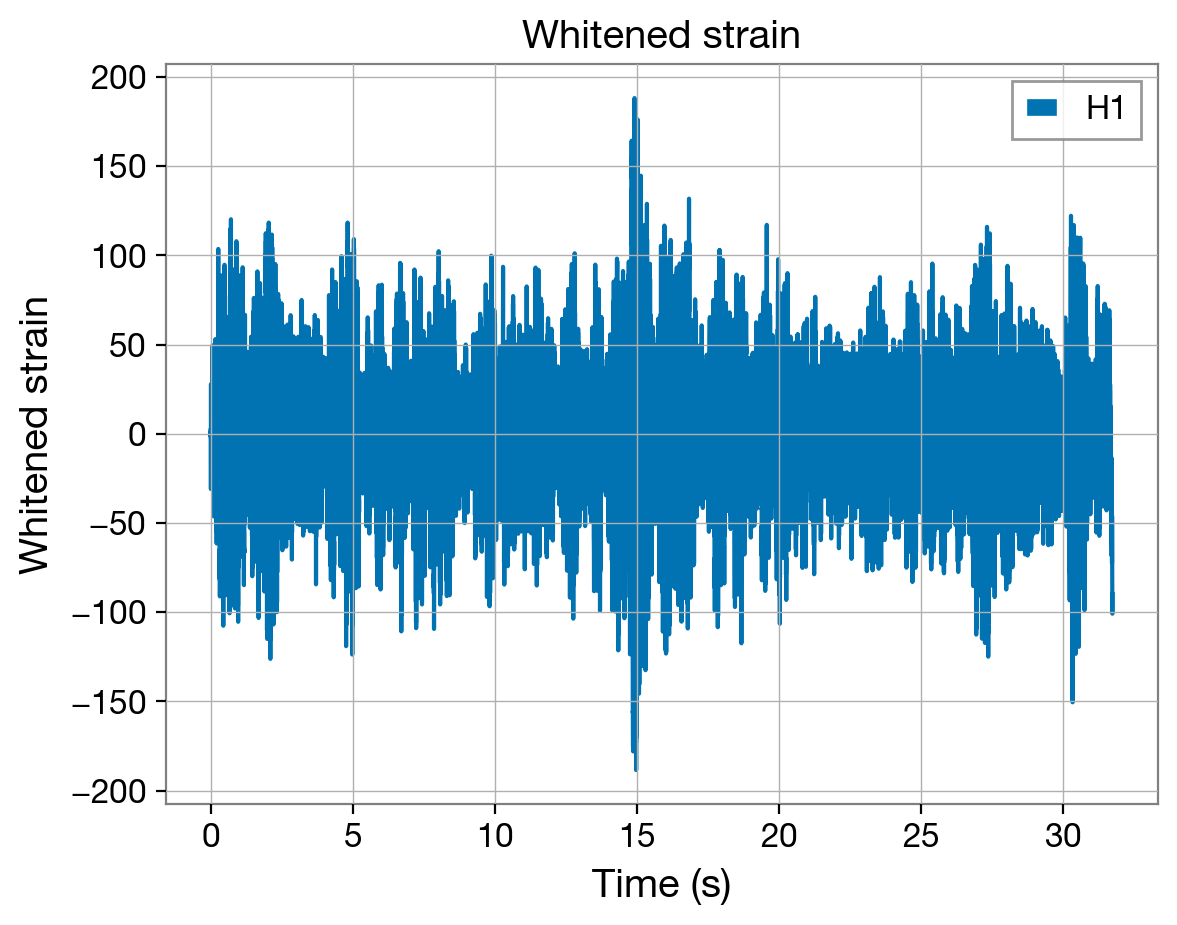

In [138]:
import matplotlib.pyplot as plt

plt.figure()

for ifo in ["H1"]:
    plt.plot(time_ds[ifo], whitened_data[ifo], label=ifo)

plt.legend()
plt.title("Whitened strain")
plt.xlabel("Time (s)")
plt.ylabel("Whitened strain")
plt.show()

In [116]:
wfs_full = waveform_h5s.load_waveform_h5py(f'../../tdinf/waveform_h5s.py')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../tdinf/waveform_h5s.py', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [47]:
wfs_full_whitened = utils.whiten_wfs_TD(wfs_full['samples'], L_dict)

NameError: name 'wfs_full' is not defined